<div style="background: linear-gradient(135deg, #0f172a, #1e293b); color:white; padding:25px; border-radius:10px; 
            text-align:center; font-family:'Segoe UI', sans-serif;">

  <h1 style="margin-bottom:8px;">Market Sentiment Analysis from Tweets</h1>
  <h3 style="margin-top:0; font-style:italic; font-weight:normal; color:#94a3b8;">
    Exploratory Data Analysis (EDA)
  </h3>

  <hr style="width:60%; border:1px solid #475569; margin:15px auto;">

  <p style="margin:5px 0; font-size:15px;">
    <b>Group Project</b> - Text Mining (2025/2026)
  </p>
  <p style="margin:0; font-size:13px; color:#cbd5e1;">
    Master in Data Science and Advanced Analytics - Nova Information Management School
  </p>
</div>

<br>

<div style="background-color:#1e293b; color:#e2e8f0; padding:15px 20px; border-left:5px solid #475569; 
            border-radius:6px; font-family:'Segoe UI', sans-serif; font-size:14px;">

  <b>Notebook Description</b><br>
  <b>Goal:</b> classify tweets as <b>Bearish (0)</b>, <b>Bullish (1)</b>, or <b>Neutral (2)</b> using NLP techniques.

  <br>
  This notebook covers <b>Data Exploration</b>: understanding the structure, distribution, and linguistic characteristics of the training corpus before any modelling.
</div>

**<h3>Table of Contents</h3>**
* [1. Environment Setup](#1-environment-setup)
* [2. Data Exploration](#2-data-exp)

<div id="1-environment-setup" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">
    1. Setup
  </h2>
</div>

# EDA - Market Sentiment Analysis from Tweets

**Goal:** classify tweets as **Bearish (0)**, **Bullish (1)**, or **Neutral (2)** using NLP techniques.

This notebook covers **Data Exploration**: understanding the structure, distribution, and linguistic characteristics of the training corpus before any modelling.

**Datasets:**
- `train.csv` - 9,543 tweets with labels (0=Bearish, 1=Bullish, 2=Neutral)
- `test.csv`  - 2,388 tweets without labels (predictions to be submitted)

## 1.1 Imports

In [1]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import bigrams as nltk_bigrams
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException
from tqdm import tqdm

nltk.download('punkt',        quiet=True)
nltk.download('punkt_tab',    quiet=True)
nltk.download('stopwords',    quiet=True)
nltk.download('vader_lexicon',quiet=True)

sns.set_theme(style='whitegrid')

LABEL_NAMES = {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}
PALETTE     = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}
ORDER       = ['Bearish', 'Bullish', 'Neutral']
CLASS_PAL   = {'Bearish': PALETTE[0], 'Bullish': PALETTE[1], 'Neutral': PALETTE[2]}

## 1.2 Dataset Import

In [2]:
train_df = pd.read_csv('../data/train.csv')
test_df  = pd.read_csv('../data/test.csv')

print(f'Train : {len(train_df):,} tweets | columns: {train_df.columns.tolist()}')
print(f'Test  : {len(test_df):,}  tweets | columns: {test_df.columns.tolist()}')
print()

pd.set_option('display.max_colwidth', None)

# quick sanity check of the data
for label in [0, 1, 2]:
    print(f'Label {label} ({LABEL_NAMES[label]}):')
    display(train_df[train_df['label'] == label].head(2))
    print("=" * 80)

Train : 9,543 tweets | columns: ['text', 'label']
Test  : 2,388  tweets | columns: ['id', 'text']

Label 0 (Bearish):


,text,label
0,$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT,0
1,$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3,0


Label 1 (Bullish):


,text,label
126,$ALTG: Dougherty & Company starts at Buy,1
127,$AMD - AMD's Navi shows strong adoption - BofA https://t.co/WnCksfl1gX,1


Label 2 (Neutral):


,text,label
358,$LB - MKM Partners puts a number on Victoria's Secret https://t.co/VSzHLqLBgE,2
359,$WING - Baird returns to Wingstop bull camp https://t.co/KfPaweOVgo,2


<div id="2-data-exp" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">
    2. Data Exploration
  </h2>
</div>

## 2.1 Basic Statistics

In [3]:
print('=== TRAIN SET ===')
print(f'Shape       : {train_df.shape}')
print(f'Missing vals: {train_df.isna().sum().to_dict()}')
print(f'Duplicates  : {train_df.duplicated(subset="text").sum()}')
print()
print('=== TEST SET ===')
print(f'Shape       : {test_df.shape}')
print(f'Missing vals: {test_df.isna().sum().to_dict()}')
print(f'Duplicates  : {test_df.duplicated(subset="text").sum()}')

=== TRAIN SET ===
Shape       : (9543, 2)
Missing vals: {'text': 0, 'label': 0}
Duplicates  : 0

=== TEST SET ===
Shape       : (2388, 2)
Missing vals: {'id': 0, 'text': 0}
Duplicates  : 0


In [4]:
train_df.dtypes

text       str
label    int64
dtype: object

No duplicates, no missing values and the data types are as expected.

## 2.2 Label Distribution

In [5]:
counts = train_df['label'].value_counts().sort_index()
total  = len(train_df)

print('Class distribution (training set):')
for label, count in counts.items():
    print(f'  {label} - {LABEL_NAMES[label]:<8}: {count:,}  ({count / total * 100:.1f}%)')

majority_acc = counts.max() / total * 100
print(f'\nMajority-class baseline accuracy: {majority_acc:.1f}%')

Class distribution (training set):
  0 - Bearish : 1,442  (15.1%)
  1 - Bullish : 1,923  (20.2%)
  2 - Neutral : 6,178  (64.7%)

Majority-class baseline accuracy: 64.7%


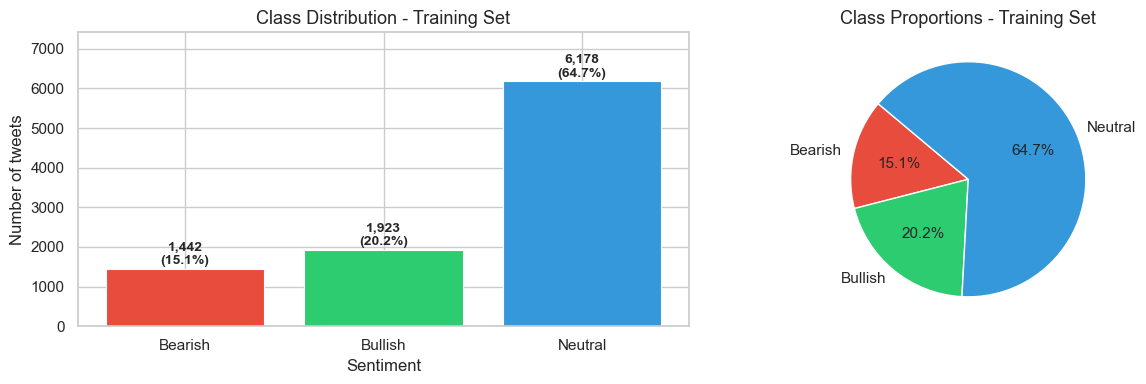

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

label_labels = [LABEL_NAMES[l] for l in counts.index]
bar_colors   = [PALETTE[l] for l in counts.index]
bars = axes[0].bar(label_labels, counts.values, color=bar_colors, edgecolor='white', linewidth=0.8)
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 40,
                 f'{count:,}\n({count/total*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Class Distribution - Training Set', fontsize=13)
axes[0].set_ylabel('Number of tweets')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylim(0, counts.max() * 1.20)

axes[1].pie(counts.values, labels=label_labels, colors=bar_colors,
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 11})
axes[1].set_title('Class Proportions - Training Set', fontsize=13)

plt.tight_layout()
plt.show()

The dataset is **highly imbalanced**. Neutral tweets dominate (~64.7%), while Bearish (15.1%) and Bullish (20.2%) are underrepresented. A naive classifier that always predicts Neutral achieves ~64.7% accuracy. Models must be evaluated with **per-class F1** rather than raw accuracy alone. Techniques like class-weighted losses or oversampling (SMOTE) may be needed.

## 2.3 Tweet Length Analysis

In [7]:
train_df['word_count'] = train_df['text'].str.split().str.len()
train_df['char_count'] = train_df['text'].str.len()
train_df['label_name'] = train_df['label'].map(LABEL_NAMES)

print('Word count statistics (overall):')
print(train_df['word_count'].describe().round(1))
print()
print('Word count statistics by class:')
print(train_df.groupby('label_name')['word_count'].describe().round(1))

Word count statistics (overall):
count    9543.0
mean       12.2
std         4.7
min         1.0
25%         9.0
50%        11.0
75%        15.0
max        32.0
Name: word_count, dtype: float64

Word count statistics by class:
             count  mean  std  min  25%   50%   75%   max
label_name                                               
Bearish     1442.0  12.0  4.3  3.0  9.0  11.0  15.0  32.0
Bullish     1923.0  11.9  4.3  2.0  9.0  11.0  14.0  29.0
Neutral     6178.0  12.3  4.8  1.0  9.0  12.0  16.0  29.0


/var/folders/kx/33c35mzs1g95d1knp21wl0480000gn/T/ipykernel_32857/1404018305.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='label_name', y='word_count', order=ORDER, palette=CLASS_PAL, ax=axes[1])
/var/folders/kx/33c35mzs1g95d1knp21wl0480000gn/T/ipykernel_32857/1404018305.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=train_df, x='label_name', y='char_count', order=ORDER, palette=CLASS_PAL, ax=axes[2], inner='box')


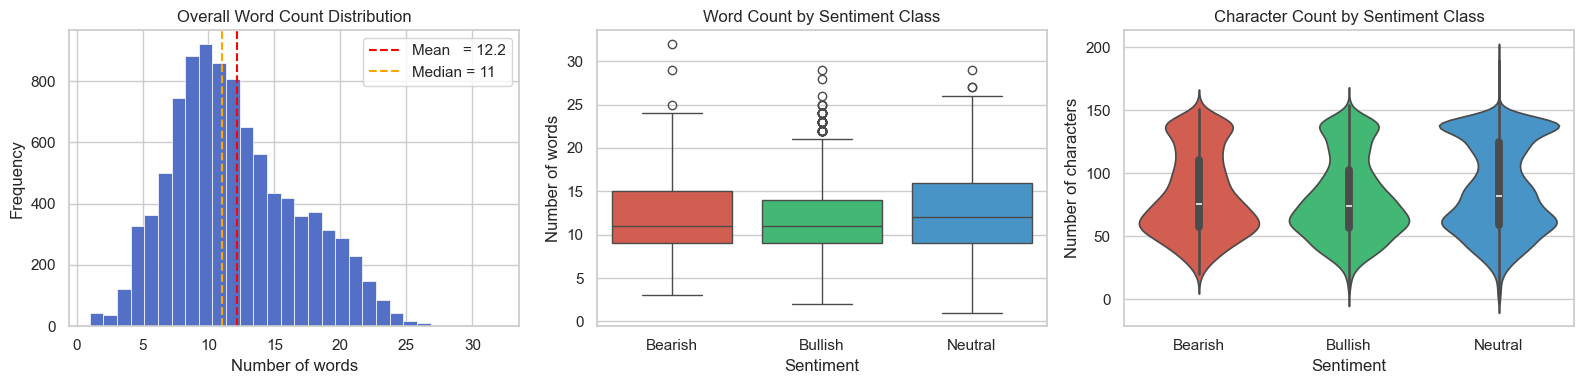

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(train_df['word_count'], bins=30, color='#5470c6', edgecolor='white', linewidth=0.5)
axes[0].axvline(train_df['word_count'].mean(),   color='red',    linestyle='--', label=f"Mean   = {train_df['word_count'].mean():.1f}")
axes[0].axvline(train_df['word_count'].median(), color='orange', linestyle='--', label=f"Median = {train_df['word_count'].median():.0f}")
axes[0].set_title('Overall Word Count Distribution')
axes[0].set_xlabel('Number of words')
axes[0].set_ylabel('Frequency')
axes[0].legend()

sns.boxplot(data=train_df, x='label_name', y='word_count', order=ORDER, palette=CLASS_PAL, ax=axes[1])
axes[1].set_title('Word Count by Sentiment Class')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Number of words')

sns.violinplot(data=train_df, x='label_name', y='char_count', order=ORDER, palette=CLASS_PAL, ax=axes[2], inner='box')
axes[2].set_title('Character Count by Sentiment Class')
axes[2].set_xlabel('Sentiment')
axes[2].set_ylabel('Number of characters')

plt.tight_layout()
plt.show()

Tweets are very short - median ~11 words, max ~32. The length distributions are similar across classes, so tweet length alone is not a strong discriminative feature. There are also tweets with a number of words as low as 1. These tweets may lack sufficient lack for reliable sentiment prediction and could introduce noise into the model. These probably will need to be treated later.

## 2.4 Sample Tweets per Class

In [9]:
for label in [0, 1, 2]:
    print(f'=== {LABEL_NAMES[label].upper()} (label={label}) ===')
    samples = train_df[train_df['label'] == label]['text'].head(3).tolist()
    for i, s in enumerate(samples, 1):
        print(f'  {i}. {s}')
    print()

=== BEARISH (label=0) ===
  1. $BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
  2. $CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3
  3. $CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb

=== BULLISH (label=1) ===
  1. $ALTG: Dougherty & Company starts at Buy
  2. $AMD - AMD's Navi shows strong adoption - BofA https://t.co/WnCksfl1gX
  3. $ANCUF: BMO Capital Markets ups to Outperform

=== NEUTRAL (label=2) ===
  1. $LB - MKM Partners puts a number on Victoria's Secret https://t.co/VSzHLqLBgE
  2. $WING - Baird returns to Wingstop bull camp https://t.co/KfPaweOVgo
  3. Analysts React To FCC Decision On Intelsat C-Band Spectrum Auction



Bearish tweets cite analyst downgrades and negative outlook. Bullish tweets mention upgrades and growth expectations. Neutral tweets are factual statements without a clear directional opinion. Ticker symbols (`$BYND`, `$CCL`) and URLs are ubiquitous noise that must be addressed in preprocessing.

## 2.5 Special Tokens: Cashtags, Hashtags, URLs, Mentions

In [10]:
def count_pattern(series, pattern):
    return series.str.findall(pattern).str.len()

train_df['n_cashtags'] = count_pattern(train_df['text'], r'\$[A-Z]+')
train_df['n_hashtags'] = count_pattern(train_df['text'], r'#\w+')
train_df['n_urls']     = count_pattern(train_df['text'], r'https?://\S+')
train_df['n_mentions'] = count_pattern(train_df['text'], r'@\w+')

special = ['n_cashtags', 'n_hashtags', 'n_urls', 'n_mentions']
print('Special token counts (training set):')
print(train_df[special].describe().round(2))

Special token counts (training set):
       n_cashtags  n_hashtags   n_urls  n_mentions
count     9543.00     9543.00  9543.00     9543.00
mean         0.21        0.23     0.53        0.04
std          0.81        0.75     0.62        0.23
min          0.00        0.00     0.00        0.00
25%          0.00        0.00     0.00        0.00
50%          0.00        0.00     0.00        0.00
75%          0.00        0.00     1.00        0.00
max         23.00        7.00     3.00        8.00


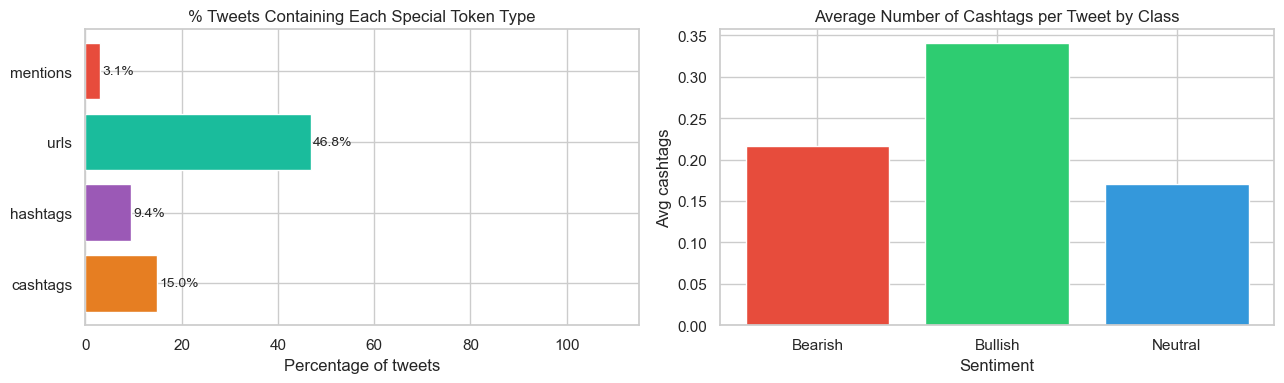

In [11]:
has_any = {col.replace('n_', ''): (train_df[col] > 0).mean() * 100 for col in special}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bars = axes[0].barh(list(has_any.keys()), list(has_any.values()),
                    color=['#e67e22', '#9b59b6', '#1abc9c', '#e74c3c'])
for bar, val in zip(bars, has_any.values()):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=10)
axes[0].set_title('% Tweets Containing Each Special Token Type')
axes[0].set_xlabel('Percentage of tweets')
axes[0].set_xlim(0, max(has_any.values()) * 1.15)

avg_cash = train_df.groupby('label_name')['n_cashtags'].mean().reindex(ORDER)
axes[1].bar(avg_cash.index, avg_cash.values, color=[PALETTE[0], PALETTE[1], PALETTE[2]])
axes[1].set_title('Average Number of Cashtags per Tweet by Class')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Avg cashtags')

plt.tight_layout()
plt.show()

~46,8% of tweets contain a URL and ~15% contain a cashtag. URLs are noise and should always be stripped. Cashtags identify the stock being discussed - they can be removed, kept as-is, or replaced with a generic `#STOCK` token.

## 2.6 Most Frequent Words (Raw vs Cleaned)

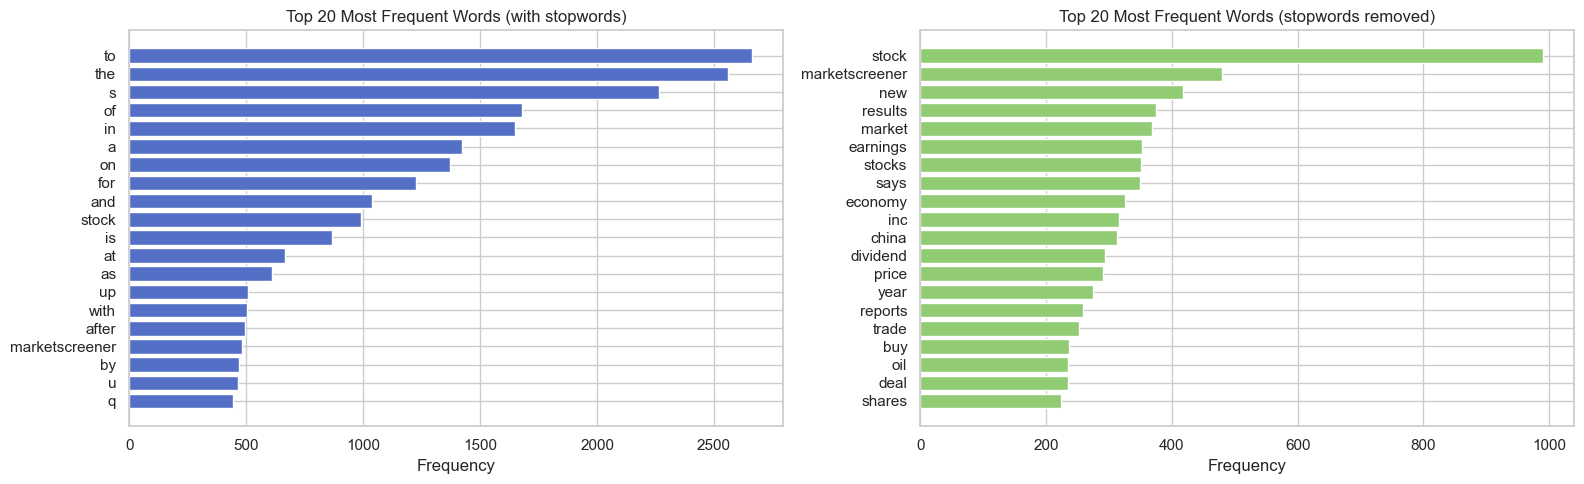

In [12]:
stop = set(stopwords.words('english'))

def get_top_words(texts, n=20, remove_stop=False):
    all_words = []
    for text in texts:
        text = str(text).lower()
        text = re.sub(r'https?://\S+', '', text)
        text = re.sub(r'[^a-zA-Z\s]', ' ', text)
        tokens = text.split()
        if remove_stop:
            tokens = [t for t in tokens if t not in stop and len(t) > 1]
        all_words.extend(tokens)
    return Counter(all_words).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_raw = get_top_words(train_df['text'], n=20, remove_stop=False)
words_raw, counts_raw = zip(*top_raw)
axes[0].barh(words_raw[::-1], counts_raw[::-1], color='#5470c6')
axes[0].set_title('Top 20 Most Frequent Words (with stopwords)')
axes[0].set_xlabel('Frequency')

top_clean = get_top_words(train_df['text'], n=20, remove_stop=True)
words_clean, counts_clean = zip(*top_clean)
axes[1].barh(words_clean[::-1], counts_clean[::-1], color='#91cc75')
axes[1].set_title('Top 20 Most Frequent Words (stopwords removed)')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

Before removing stopwords, function words (`the`, `to`, `of`) dominate. After removal, domain-specific terms emerge: `stock`, `marketscreener`, `results`, `market`, `earnings` - these will be valuable features for classification.

## 2.7 Most Frequent Words per Class

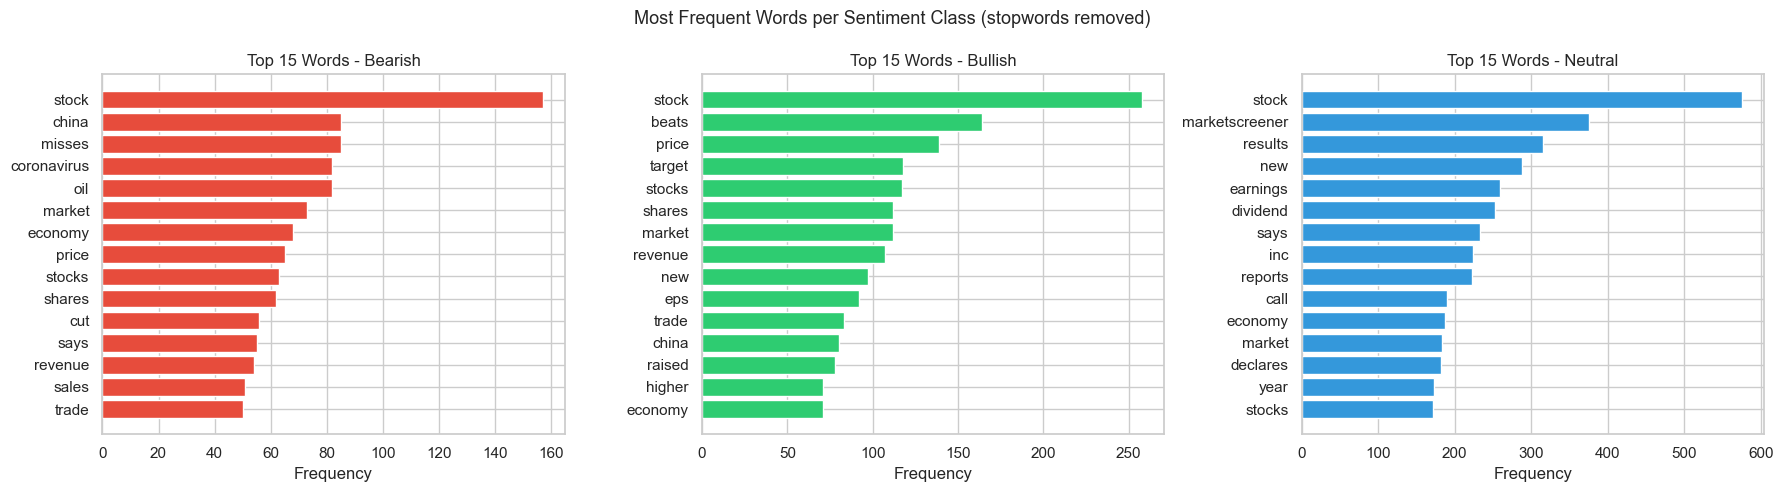

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, label in zip(axes, [0, 1, 2]):
    texts = train_df[train_df['label'] == label]['text']
    top   = get_top_words(texts, n=15, remove_stop=True)
    words, cnts = zip(*top)
    ax.barh(words[::-1], cnts[::-1], color=PALETTE[label])
    ax.set_title(f'Top 15 Words - {LABEL_NAMES[label]}')
    ax.set_xlabel('Frequency')

plt.suptitle('Most Frequent Words per Sentiment Class (stopwords removed)', fontsize=13)
plt.tight_layout()
plt.show()

In [14]:
records = []
for label in [0, 1, 2]:
    texts = train_df[train_df['label'] == label]['text']
    for word, freq in get_top_words(texts, n=25, remove_stop=True):
        records.append({'label': label, 'word': word, 'freq': freq})

word_freq = pd.DataFrame(records)
word_freq['label_name'] = word_freq['label'].map(LABEL_NAMES)

fig = px.treemap(
    word_freq,
    path=['label_name', 'word'],
    values='freq',
    color='label_name',
    color_discrete_map=CLASS_PAL,
    title='Top-25 Words per Sentiment Class (Treemap)',
)
fig.update_traces(
    textinfo='label+value',
    hovertemplate='<b>%{label}</b><br>Count: %{value:,}<extra></extra>',
)
fig.update_layout(margin=dict(t=50, l=10, r=10, b=10), font=dict(size=13))
fig.show()

- **Bearish:** `stock`, `china`, `misses`, `coronavirus`, `oil` - linked to negative macroeconomic events (pandemic, trade war, oil price drops) and results below expectations.
- **Bullish:** `stock`, `beats`, `price`, `target`, `shares` - dominated by earnings beats and upward price target revisions.
- **Neutral:** `stock`, `marketscreener`, `results`, `earnings`, `dividend` - factual and descriptive language with no clear directional sentiment.


Note: `stock` is the most frequent word across all three classes and therefore has low discriminative power - it could be treated as an additional domain stopword. In contrast, `beats` (Bullish) and `misses` (Bearish) are highly class-specific and will be very relevant features for classification.

## 2.8 Word Clouds per Class

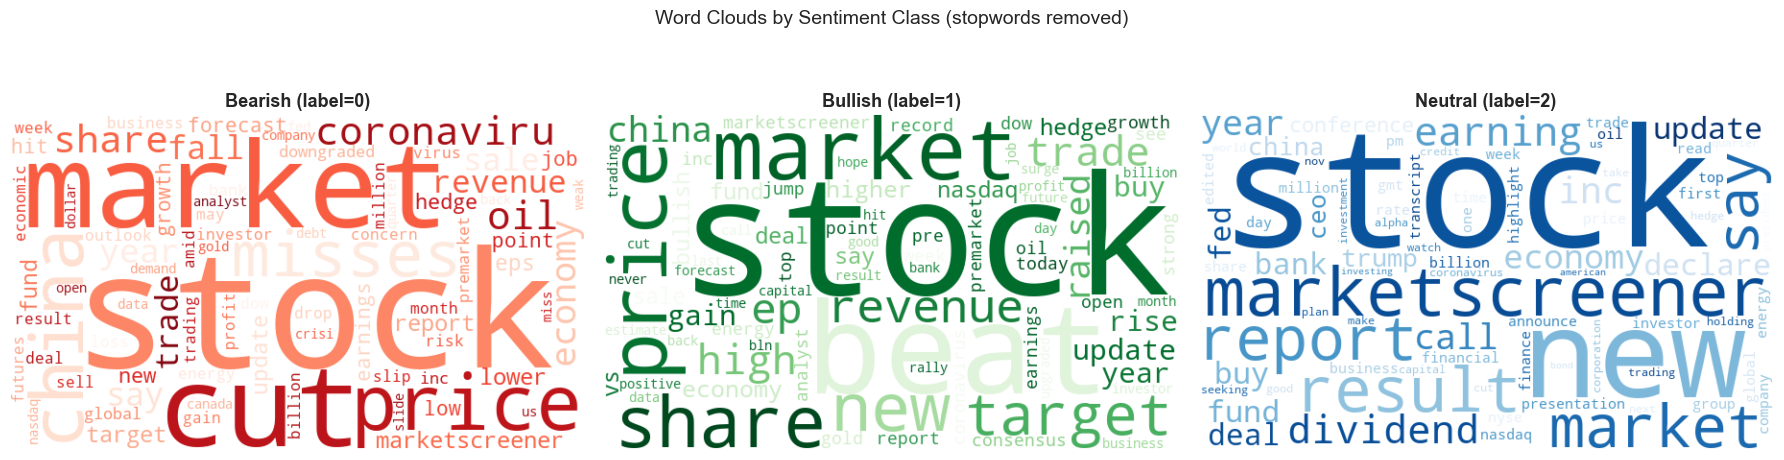

In [15]:
def make_wordcloud(texts, colormap):
    corpus = ' '.join(str(t) for t in texts).lower()
    corpus = re.sub(r'https?://\S+', '', corpus)
    corpus = re.sub(r'[^a-zA-Z\s]', ' ', corpus)
    corpus = ' '.join(w for w in corpus.split() if w not in stop and len(w) > 1)
    return WordCloud(width=600, height=350, background_color='white',
                     colormap=colormap, max_words=80, collocations=False).generate(corpus)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, label, cmap in zip(axes, [0, 1, 2], ['Reds', 'Greens', 'Blues']):
    ax.imshow(make_wordcloud(train_df[train_df['label'] == label]['text'], cmap), interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{LABEL_NAMES[label]} (label={label})', fontsize=13, fontweight='bold')

plt.suptitle('Word Clouds by Sentiment Class (stopwords removed)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 2.9 Top Cashtags (Most Mentioned Stocks)

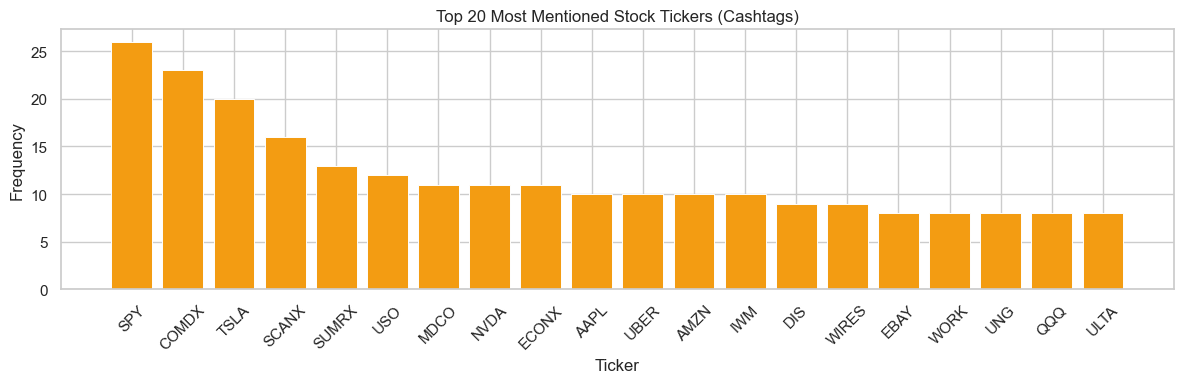

Unique tickers in training set: 1,208


In [16]:
all_cashtags = []
for text in train_df['text']:
    all_cashtags.extend(re.findall(r'\$([A-Z]+)', str(text)))

top_cash = Counter(all_cashtags).most_common(20)
tickers, tcounts = zip(*top_cash)

plt.figure(figsize=(12, 4))
plt.bar(tickers, tcounts, color='#f39c12', edgecolor='white', linewidth=0.7)
plt.title('Top 20 Most Mentioned Stock Tickers (Cashtags)')
plt.ylabel('Frequency')
plt.xlabel('Ticker')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Unique tickers in training set: {len(set(all_cashtags)):,}')

A large variety of tickers are mentioned, making them a very sparse feature. The most frequent ones may carry implicit sentiment signals. Whether to keep, replace, or drop cashtags is an important preprocessing decision.

## 2.10 Bigram Analysis per Class

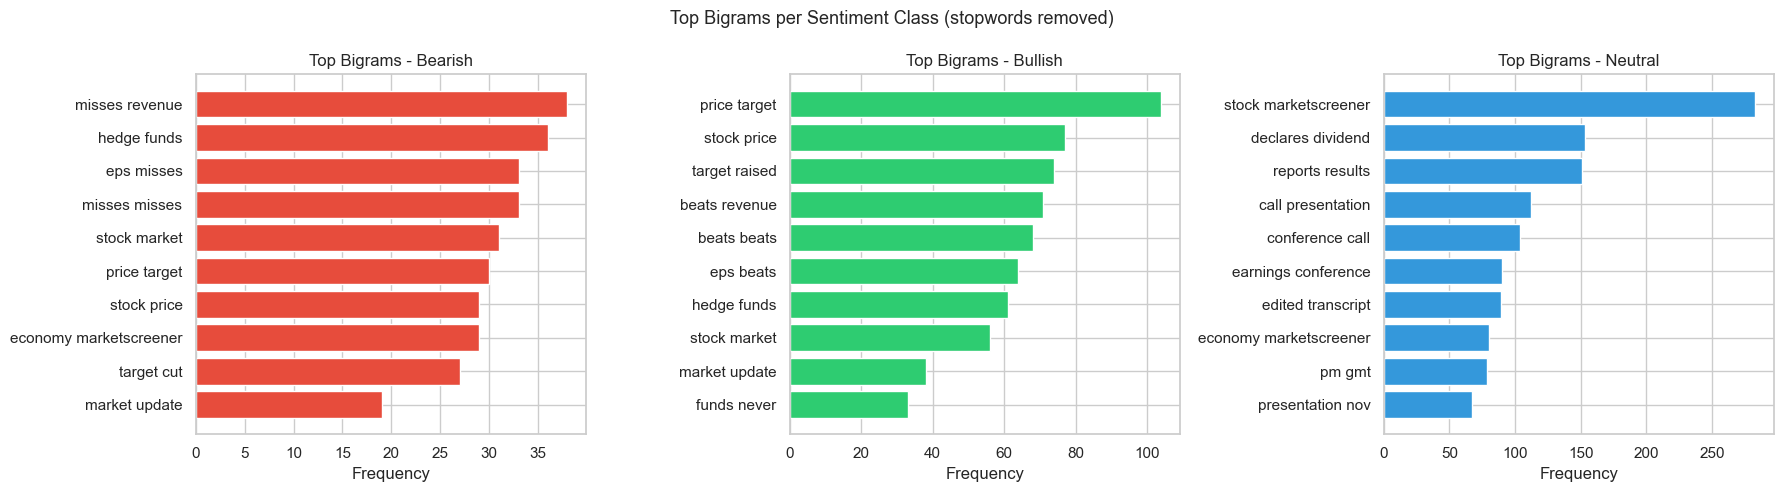

In [17]:
def top_bigrams(texts, n=10):
    bg_counter = Counter()
    for text in texts:
        text = str(text).lower()
        text = re.sub(r'https?://\S+', '', text)
        text = re.sub(r'[^a-zA-Z\s]', ' ', text)
        tokens = [t for t in text.split() if t not in stop and len(t) > 1]
        bg_counter.update(nltk_bigrams(tokens))
    return [(f'{a} {b}', c) for (a, b), c in bg_counter.most_common(n)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, label in zip(axes, [0, 1, 2]):
    bgs = top_bigrams(train_df[train_df['label'] == label]['text'], n=10)
    bg_words, bg_counts = zip(*bgs)
    ax.barh(bg_words[::-1], bg_counts[::-1], color=PALETTE[label])
    ax.set_title(f'Top Bigrams - {LABEL_NAMES[label]}')
    ax.set_xlabel('Frequency')

plt.suptitle('Top Bigrams per Sentiment Class (stopwords removed)', fontsize=13)
plt.tight_layout()
plt.show()

- **Bearish:** `misses revenue`, `hedge funds`, `eps misses`, `misses misses`, `target cut` - centred around earnings misses and negative analyst actions such as price target cuts.
- **Bullish:** `price target`, `stock price`, `target raised`, `beats revenue`, `beats beats`, `eps beats` - dominated by upward target revisions and earnings beats, the mirror image of Bearish.
- **Neutral:** `stock marketscreener`, `declares dividend`, `reports results`, `call presentation`, `conference call` - factual corporate event language with no directional sentiment (dividend declarations, earnings call announcements, transcripts).

Note: `hedge funds` and `market update` appear in both Bearish and Bullish, suggesting they are not discriminative on their own. The most class-specific bigrams are `beats beats` / `eps beats` (Bullish) and `eps misses` / `misses misses` (Bearish) - these will be strong TF-IDF features with `ngram_range=(1,2)`.

## 2.11 Exclusive Vocabulary per Class

Words that appear **only** in one class and never in the other two - the most class-specific signals in the corpus.

In [18]:
def get_word_counter(texts):
    counter = Counter()
    for text in texts:
        text = str(text).lower()
        text = re.sub(r'https?://\S+', '', text)
        text = re.sub(r'[^a-zA-Z\s]', ' ', text)
        counter.update(t for t in text.split() if t not in stop and len(t) > 1)
    return counter

counters = {label: get_word_counter(train_df[train_df['label'] == label]['text']) for label in [0, 1, 2]}
word_sets = {label: set(c.keys()) for label, c in counters.items()}

print('Exclusive vocabulary sizes:')
for label in [0, 1, 2]:
    others = set().union(*[word_sets[l] for l in [0, 1, 2] if l != label])
    excl   = word_sets[label] - others
    print(f'  {LABEL_NAMES[label]}: {len(excl):,} exclusive words')
    top_excl = sorted(excl, key=lambda w: counters[label][w], reverse=True)[:10]
    print(f'    Top 10: {top_excl}')
    print()

Exclusive vocabulary sizes:
  Bearish: 984 exclusive words
    Top 10: ['plunges', 'sinks', 'tumble', 'downgrade', 'headwinds', 'tumbles', 'gamestop', 'tumbled', 'cymabay', 'lakewood']

  Bullish: 1,208 exclusive words
    Top 10: ['climbs', 'jumped', 'levi', 'inpx', 'ounce', 'bounces', 'intercept', 'hasbro', 'icpt', 'climbed']

  Neutral: 8,304 exclusive words
    Top 10: ['edited', 'gmt', 'preview', 'mutual', 'retirement', 'old', 'democrats', 'director', 'burn', 'democratic']



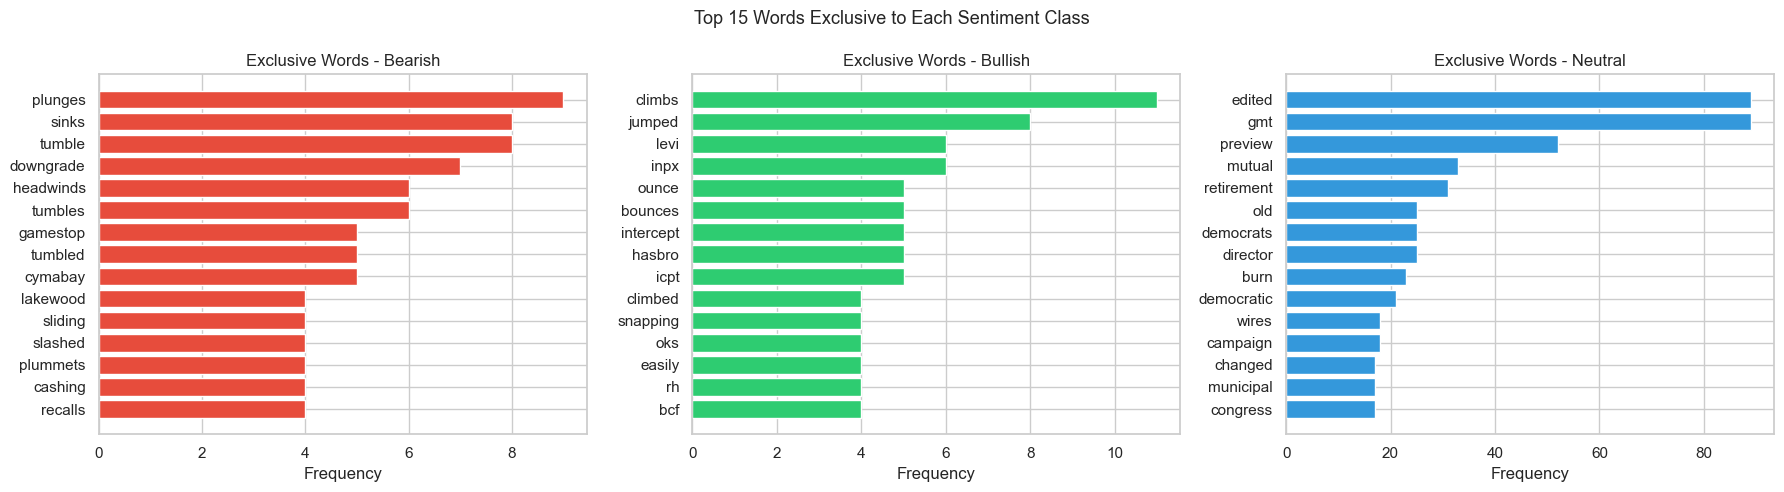

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, label in zip(axes, [0, 1, 2]):
    others   = set().union(*[word_sets[l] for l in [0, 1, 2] if l != label])
    excl     = word_sets[label] - others
    top_excl = sorted(excl, key=lambda w: counters[label][w], reverse=True)[:15]
    excl_counts = [counters[label][w] for w in top_excl]
    ax.barh(top_excl[::-1], excl_counts[::-1], color=PALETTE[label])
    ax.set_title(f'Exclusive Words - {LABEL_NAMES[label]}')
    ax.set_xlabel('Frequency')

plt.suptitle('Top 15 Words Exclusive to Each Sentiment Class', fontsize=13)
plt.tight_layout()
plt.show()

- **Bearish:** `plunges`, `sinks`, `tumble`, `downgrade`, `headwinds`, `slashed`, `underperform` - strongly negative words describing sharp price drops, analyst downgrades, and deteriorating conditions.
- **Bullish:** `climbs`, `jumped`, `bounces` - upward price movement verbs, alongside company-specific names (`levi`, `hasbro`, `intercept`) that appear exclusively in a bullish context in this corpus.
- **Neutral:** `edited`, `gmt`, `preview`, `mutual`, `retirement`, `director`, `democrats`, `campaign`, `congress`, `municipal` - broad factual vocabulary covering corporate governance, politics, and general financial reporting, reflecting the class's larger and more diverse coverage.

Note: many Bullish and Neutral exclusive words are rare company names or low-frequency terms (`inpx`, `icpt`, `aquestive`, `gmt`), which limits their generalisation to unseen data. The most reliable exclusive signals are the high-frequency Bearish movement verbs (`plunges`, `tumble`, `downgrade`) - clear and reusable indicators of negative sentiment.

## 2.12 Train / Test Distribution Comparison

Before modelling, we verify that the test set has a similar linguistic distribution to the training set - if not, the model may generalise poorly.

In [20]:
test_df['word_count'] = test_df['text'].str.split().str.len()
test_df['char_count'] = test_df['text'].str.len()
test_df['n_urls']     = count_pattern(test_df['text'], r'https?://\S+')
test_df['n_cashtags'] = count_pattern(test_df['text'], r'\$[A-Z]+')

comparison = pd.DataFrame({
    'Metric'         : ['Word count (mean)', 'Word count (median)', 'Char count (mean)',
                        '% with URL', '% with cashtag'],
    'Train'          : [
        train_df['word_count'].mean(),
        train_df['word_count'].median(),
        train_df['char_count'].mean(),
        (train_df['n_urls'] > 0).mean() * 100,
        (train_df['n_cashtags'] > 0).mean() * 100,
    ],
    'Test'           : [
        test_df['word_count'].mean(),
        test_df['word_count'].median(),
        test_df['char_count'].mean(),
        (test_df['n_urls'] > 0).mean() * 100,
        (test_df['n_cashtags'] > 0).mean() * 100,
    ]
})
comparison['Diff'] = (comparison['Test'] - comparison['Train']).round(2)
print(comparison.round(2).to_string(index=False))

             Metric  Train  Test  Diff
  Word count (mean)  12.18 12.32  0.14
Word count (median)  11.00 12.00  1.00
  Char count (mean)  85.82 86.85  1.04
         % with URL  46.84 47.82  0.98
     % with cashtag  14.97 15.45  0.48


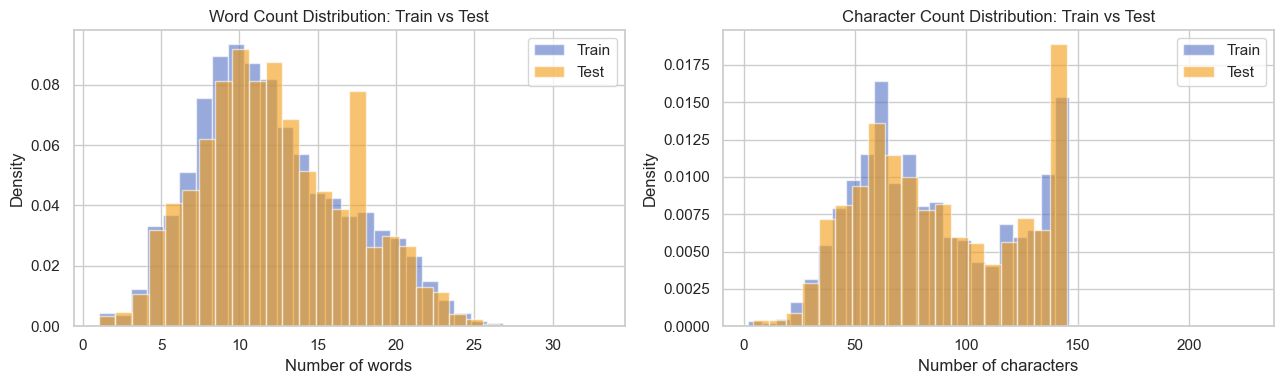

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(train_df['word_count'], bins=30, alpha=0.6, label='Train', color='#5470c6', density=True)
axes[0].hist(test_df['word_count'],  bins=30, alpha=0.6, label='Test',  color='#f39c12', density=True)
axes[0].set_title('Word Count Distribution: Train vs Test')
axes[0].set_xlabel('Number of words')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].hist(train_df['char_count'], bins=30, alpha=0.6, label='Train', color='#5470c6', density=True)
axes[1].hist(test_df['char_count'],  bins=30, alpha=0.6, label='Test',  color='#f39c12', density=True)
axes[1].set_title('Character Count Distribution: Train vs Test')
axes[1].set_xlabel('Number of characters')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

The train and test distributions are very similar in tweet length, URL presence, and cashtag usage. This suggests no obvious domain shift between splits - a model that performs well on train/validation should generalise reasonably to the test set.

## 2.13 Vocabulary Overlap: Out-of-Vocabulary (OOV) Analysis

OOV words are tokens in the test set that never appear in the training set. BoW/TF-IDF models cannot represent OOV words - they are silently dropped. High OOV rates hurt performance.

In [22]:
def extract_vocab(texts):
    vocab = set()
    for text in texts:
        text = str(text).lower()
        text = re.sub(r'https?://\S+', '', text)
        text = re.sub(r'[^a-zA-Z\s]', ' ', text)
        vocab.update(t for t in text.split() if t not in stop and len(t) > 1)
    return vocab

train_vocab = extract_vocab(train_df['text'])
test_vocab  = extract_vocab(test_df['text'])

oov_words   = test_vocab - train_vocab
overlap     = test_vocab & train_vocab

print(f'Train vocabulary size : {len(train_vocab):,} unique words')
print(f'Test  vocabulary size : {len(test_vocab):,}  unique words')
print(f'Shared words          : {len(overlap):,}')
print(f'OOV words (test only) : {len(oov_words):,}  ({len(oov_words)/len(test_vocab)*100:.1f}% of test vocab)')

Train vocabulary size : 14,750 unique words
Test  vocabulary size : 6,725  unique words
Shared words          : 4,814
OOV words (test only) : 1,911  (28.4% of test vocab)


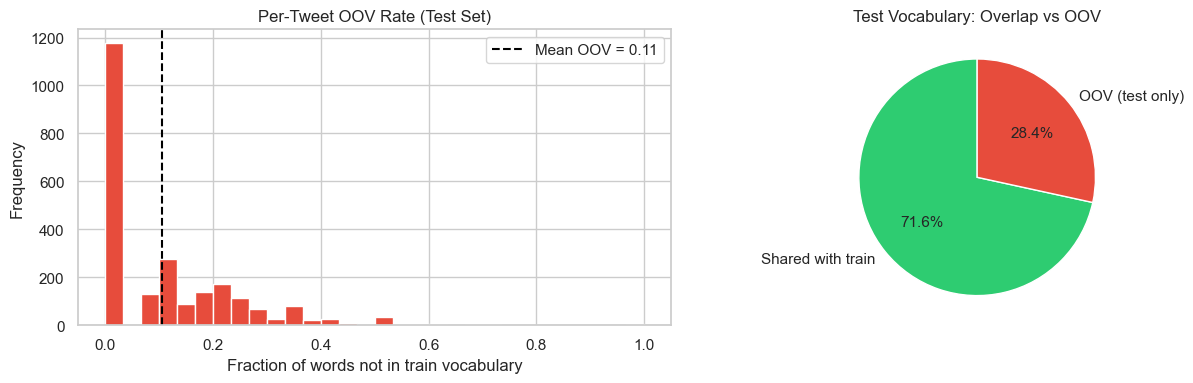


Sample OOV words: ['realistic', 'upl', 'technician', 'words', 'schmi', 'shabby', 'crisil', 'edible', 'overlooking', 'idiots', 'oliver', 'bieber', 'happier', 'inflatable', 'saudiarabianoil']


In [23]:
# Per-tweet OOV rate
def oov_rate(text, vocab):
    text = str(text).lower()
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    tokens = [t for t in text.split() if t not in stop and len(t) > 1]
    if not tokens:
        return 0.0
    return sum(1 for t in tokens if t not in vocab) / len(tokens)

test_df['oov_rate'] = test_df['text'].apply(lambda t: oov_rate(t, train_vocab))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(test_df['oov_rate'], bins=30, color='#e74c3c', edgecolor='white')
axes[0].axvline(test_df['oov_rate'].mean(), color='black', linestyle='--',
                label=f"Mean OOV = {test_df['oov_rate'].mean():.2f}")
axes[0].set_title('Per-Tweet OOV Rate (Test Set)')
axes[0].set_xlabel('Fraction of words not in train vocabulary')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Overlap pie
axes[1].pie([len(overlap), len(oov_words)],
            labels=['Shared with train', 'OOV (test only)'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Test Vocabulary: Overlap vs OOV')

plt.tight_layout()
plt.show()

print(f'\nSample OOV words: {list(oov_words)[:15]}')

28.4% of the test vocabulary never appears in the training set (OOV), while 71.6% is shared. At the tweet level, the mean OOV rate is low (~0.11), meaning the average test tweet has only ~11% of its content words unseen during training - most tweets are well covered. However, the distribution is right-skewed: a small number of tweets have very high OOV rates (up to 1.0), meaning some are composed almost entirely of unseen words.

## 2.14 Encoding Problems Check

In [24]:
#checking the existence of encoding problems
encoding_issues = train_df.apply(lambda row: row.astype(str).str.contains(r'[�Ã©Ã£ÃªÃ¢Ã¡Ã³Ã§]').any(), axis=1)
train_df[encoding_issues]

,text,label,word_count,char_count,label_name,n_cashtags,n_hashtags,n_urls,n_mentions
715,The stricken Bank of Jinzhou will unload $21 billion of assets to the central bank for less than a third of theirÃ‚Â r… https://t.co/xGuCP9lBlH,2,24,143,Neutral,0,0,1,0
2385,ItaÃƒÂº Unibanco S A : Payment of Dividends and Interest on Capital #Stock #MarketScreener https://t.co/sfvlaXYEJV https://t.co/TSbbMl9D6M,2,16,139,Neutral,0,2,2,0
2560,$MGDDF - Compagnie GÃƒÂ©nÃƒÂ©rale des Ãƒâ€°tablissements Michelin reports FY results https://t.co/2Ri09vpiOc,2,11,108,Neutral,1,0,1,0
3879,�� Here's why one great whale offers more in the fight against climate than a forest of trees https://t.co/y0UwSQWd8u,2,19,117,Neutral,0,0,1,0
3880,�� Here's why Trump Tower is now one of the least-desirable luxury buildings in NYC https://t.co/1OOQHhju0F,2,16,107,Neutral,0,0,1,0
5153,The £3bn hole in the Tory manifesto https://t.co/eSWRQRRDEL,2,8,59,Neutral,0,0,1,0
5270,"'There is more to Europe than the EU.' On #BrexitDay Louis de BerniÃ¨res, author of Captain Corelli's Mandolin, offe… https://t.co/d107tKjLZD",2,20,141,Neutral,0,1,1,0
5271,"'There is more to Europe than the EU.' On #BrexitDay Louis de BerniÃ¨res, author of Captain Corelli's Mandolin, offeâ€¦ https://t.co/d107tKjLZD",2,20,143,Neutral,0,1,1,0
5526,��Yes! We have no bananas.🎶 Watch the full video and learn why the banana could go extinct. https://t.co/a8LmzX6jKN https://t.co/Zvk25r2EUM,2,19,139,Neutral,0,0,2,0
5544,��🌍🌏Wind speeds are up globally. That's good news for renewable energy https://t.co/5HlsbJMYBR,2,12,94,Neutral,0,0,1,0


Only 17 tweets (~0.18%) show encoding artefacts (mojibake, broken emojis, currency symbols). The impact is negligible and standard preprocessing (regex cleaning, lowercasing) will handle most of these automatically - no manual correction needed.

## 2.15 Language Detection

Language detection ensures the corpus is predominantly English, as preprocessing techniques (stopwords, lemmatization, stemming) are configured for English. Non-English tweets introduce noise and will be incorrectly processed and identifying them allows for informed filtering before modelling.

In [25]:
def detect_language(text):
    try:
        return detect(text)
    except LangDetectException:
        return "error"

tqdm.pandas()
train_df['language'] = train_df['text'].progress_apply(detect_language)

lang_counts = Counter(train_df['language'])
for lang, count in lang_counts.most_common():
    print(f"{lang}: {count}")

100%|██████████| 9543/9543 [00:11<00:00, 795.75it/s] 

en: 8857
ca: 113
de: 108
es: 87
fr: 84
sv: 61
da: 40
no: 31
nl: 30
it: 29
af: 21
pt: 13
tl: 11
et: 10
id: 10
ro: 5
vi: 5
pl: 5
error: 4
so: 4
hu: 3
fi: 2
cy: 2
sl: 2
zh-cn: 1
cs: 1
hr: 1
sk: 1
ja: 1
sw: 1


In [26]:
non_english_tweets = train_df[train_df['language'] != 'en']

sample_non_english = non_english_tweets.sample(n=15, random_state=52)

for i, row in sample_non_english.iterrows():
    print(f"{row['language']} → {row['text']}\n")

es → $FMN - Federated Premier Municipal Income Fund declares $0.05 dividend https://t.co/h3rT8c1GvI

error → :)

error → https://t.co/9eZPvQhfMq

et → FLEX LNG misses on revenue

de → Is Enzo Biochem, Inc. (ENZ) Going To Burn These Hedge Funds ?

es → BlackRock declares $3.30 dividend

de → Foreign Bondholders Join Lebanese Debt Restructuring Chorus

sv → Stock Market Update: Edgewell Personal Care spikes after earnings

fr → First Choice declares $0.25 dividend

fr → "Let’s do push-ups, man." https://t.co/U8QVQkICIh

es → Exploration deepens into central bank digital currencies

ca → Nasdaq-100 futures retreat 15 points, or 0.2%

fr → BJ's Wholesale Q3 same-store sales up 1.1%; FactSet consensus up 2.0%

es → Royal Gold declares $0.28 dividend

ca → $SOL - ReneSola names new CEO, CFO after departures https://t.co/mn86Psp8tq



Inspecting a sample of non-English tweets reveals that langdetect systematically misclassifies short financial tweets - cashtags, monetary values, and domain-specific terminology confuse the probabilistic detector. No filtering will be applied based on language.

## 2.16 Punctuation, Uppercase & Numbers

Beyond cashtags and URLs, financial tweets contain other potentially discriminative signals: exclamation marks (excitement), question marks (uncertainty), ALL CAPS words (emphasis), and numerical values (prices, percentages, earnings figures). Quantifying their prevalence per class indicates whether they should be preserved as features or stripped during preprocessing.

In [27]:
# Punctuation and uppercase indicators
train_df['n_exclaim']   = train_df['text'].str.count(r'!')
train_df['n_question']  = train_df['text'].str.count(r'\?')
train_df['n_caps_word'] = train_df['text'].str.findall(r'\b[A-Z]{2,}\b').str.len()

# Numbers: integers, decimals, percentages, monetary values
train_df['n_numbers'] = train_df['text'].str.findall(r'\d+(?:[.,]\d+)?').str.len()
train_df['n_percent'] = train_df['text'].str.count(r'\d+(?:\.\d+)?\s*%')
train_df['n_money']   = train_df['text'].str.count(r'\$\d+(?:[.,]\d+)?')

extra_cols = ['n_exclaim', 'n_question', 'n_caps_word', 'n_numbers', 'n_percent', 'n_money']

# Mean count per class
per_class = train_df.groupby('label')[extra_cols].mean().round(3)
per_class.index = [LABEL_NAMES[l] for l in per_class.index]
print('Average occurrences per tweet by class:')
print(per_class)

Average occurrences per tweet by class:
         n_exclaim  n_question  n_caps_word  n_numbers  n_percent  n_money
Bearish      0.004       0.010        0.657      1.307      0.182    0.137
Bullish      0.038       0.006        0.798      1.420      0.240    0.233
Neutral      0.014       0.086        0.717      1.300      0.035    0.102


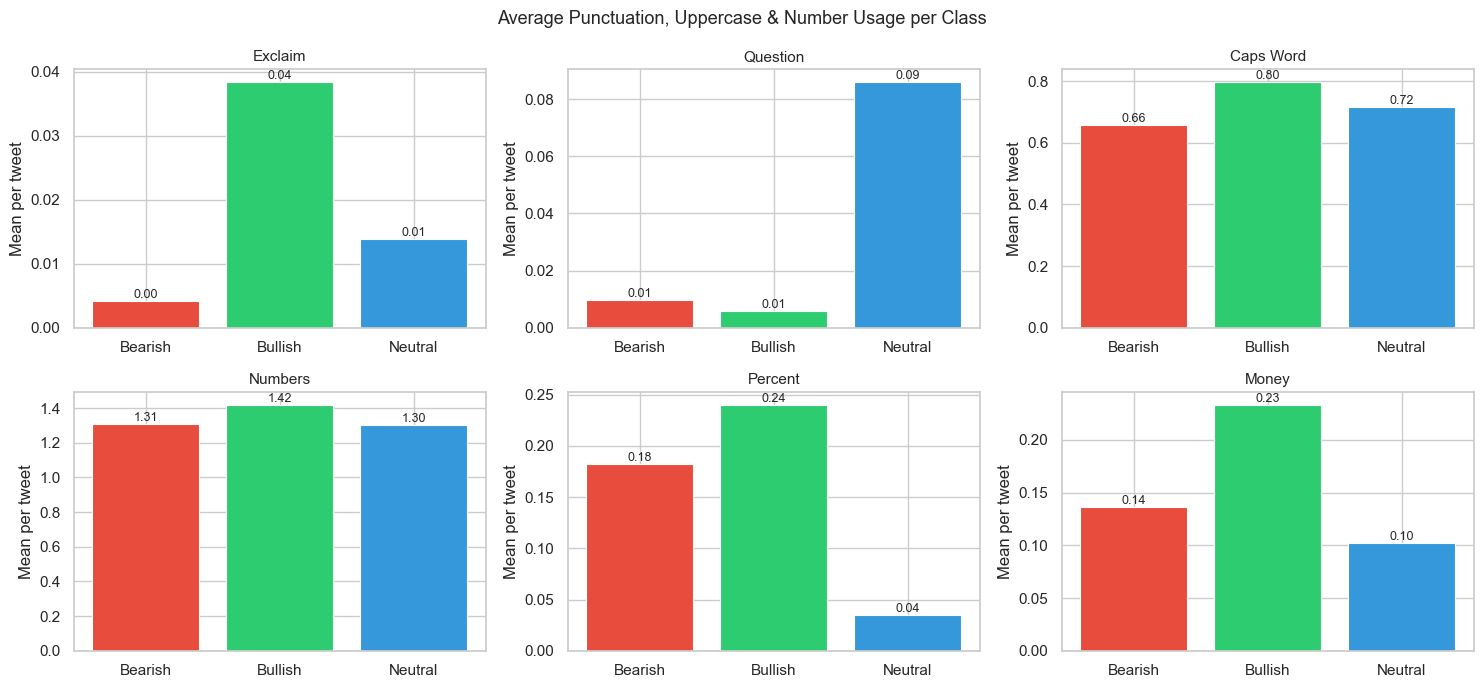

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flatten(), extra_cols):
    means = train_df.groupby('label')[col].mean()
    ax.bar([LABEL_NAMES[l] for l in means.index],
           means.values,
           color=[PALETTE[l] for l in means.index],
           edgecolor='white', linewidth=0.8)
    ax.set_title(col.replace('n_', '').replace('_', ' ').title(), fontsize=11)
    ax.set_ylabel('Mean per tweet')
    for i, v in enumerate(means.values):
        ax.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Average Punctuation, Uppercase & Number Usage per Class', fontsize=13)
plt.tight_layout()
plt.show()

Bullish tweets show ~10x more exclamations and the highest rates of `%` and `$` figures, consistent with announcements of gains and dividends. Neutral tweets concentrate question marks (headlines like "*Is X overvalued?*") and have far fewer percent/money tokens. Numbers and ALL CAPS are abundant across all classes - keeping digits during preprocessing is worth experimenting with.

## 2.17 Emoji Analysis

Emojis are common in social media and can carry strong sentiment signals. However, financial-news tweets are typically more formal than general Twitter content. We quantify their presence to decide whether to demojize them (convert to text), strip them, or leave them for transformer tokenizers to handle natively.

In [29]:
# Detect emojis using a broad unicode range (faster than the `emoji` library and no extra dependency)
emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map
    "\U0001F700-\U0001F77F"  # alchemical
    "\U0001F780-\U0001F7FF"  # geometric
    "\U0001F800-\U0001F8FF"  # supplemental arrows
    "\U0001F900-\U0001F9FF"  # supplemental symbols
    "\U0001FA00-\U0001FA6F"  # chess, etc.
    "\U0001FA70-\U0001FAFF"  # symbols
    "\U00002702-\U000027B0"  # dingbats
    "\U000024C2-\U0001F251"
    "]", flags=re.UNICODE)

train_df['n_emojis']   = train_df['text'].apply(lambda t: len(emoji_pattern.findall(str(t))))
train_df['has_emoji']  = train_df['n_emojis'] > 0

n_with    = train_df['has_emoji'].sum()
pct_with  = n_with / len(train_df) * 100
print(f'Tweets containing at least one emoji: {n_with:,} ({pct_with:.2f}%)')

# Most frequent emojis
all_emojis = []
for text in train_df['text']:
    all_emojis.extend(emoji_pattern.findall(str(text)))

if all_emojis:
    print(f'Total emoji occurrences: {len(all_emojis):,}')
    print(f'Unique emojis: {len(set(all_emojis))}')
    print('\nTop 10 emojis:')
    for emo, cnt in Counter(all_emojis).most_common(10):
        print(f'  {emo}  {cnt}')
else:
    print('No emojis found.')

Tweets containing at least one emoji: 48 (0.50%)
Total emoji occurrences: 128
Unique emojis: 95

Top 10 emojis:
  ️  11
  �  10
  ⚡  4
  ▶  3
  ✅  3
  技  2
  📈  2
  ▪  2
  🇰  2
  🔔  2


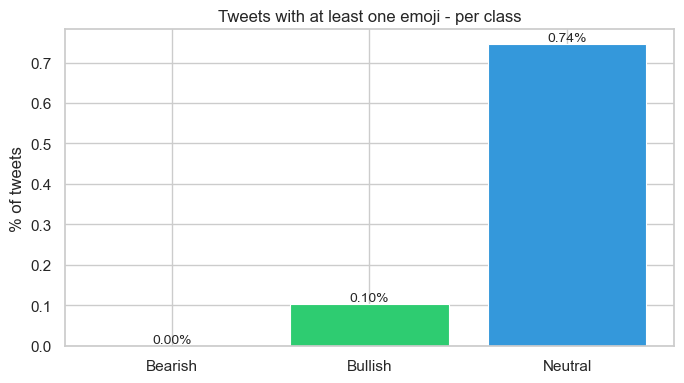

In [30]:
# Emoji presence per class
if n_with > 0:
    pct_per_class = train_df.groupby('label')['has_emoji'].mean() * 100
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar([LABEL_NAMES[l] for l in pct_per_class.index],
                  pct_per_class.values,
                  color=[PALETTE[l] for l in pct_per_class.index],
                  edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, pct_per_class.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{v:.2f}%', ha='center', va='bottom', fontsize=10)
    ax.set_title('Tweets with at least one emoji - per class')
    ax.set_ylabel('% of tweets')
    plt.tight_layout()
    plt.show()

Emojis are essentially absent (0.5% of tweets, 95 unique). Most occurrences are in Neutral tweets, often broken-encoding artefacts (`�`) or decorative symbols (`▶`, `✅`) rather than sentiment-bearing icons. Standard regex cleaning will strip them as a side-effect; no dedicated demojization step is needed.

## 2.18 Elongated Words & Other Patterns

Other text irregularities common in social media include elongated words (e.g. "soooo good"), email addresses, and unusually long tokens. Detecting them informs preprocessing - some warrant normalisation (collapsing repeated letters), while others may simply be data artefacts to leave alone.

In [31]:
# Elongated words: same letter repeated 3+ times (e.g. "loooove")
elongated_pattern = re.compile(r'\b\w*([a-zA-Z])\1{2,}\w*\b')

# Emails
email_pattern = re.compile(r'\b[\w.-]+@[\w.-]+\.\w+\b')

# Very long "words" (likely concatenated noise / hashtags / URL fragments)
def long_tokens(text, threshold=20):
    return [t for t in str(text).split() if len(t) >= threshold]

train_df['n_elongated'] = train_df['text'].apply(lambda t: len(elongated_pattern.findall(str(t))))
train_df['n_emails']    = train_df['text'].apply(lambda t: len(email_pattern.findall(str(t))))
train_df['n_longtoken'] = train_df['text'].apply(lambda t: len(long_tokens(t)))

print(f"Tweets with elongated words : {(train_df['n_elongated'] > 0).sum():,} "
      f"({(train_df['n_elongated'] > 0).mean()*100:.2f}%)")
print(f"Tweets with email addresses : {(train_df['n_emails']    > 0).sum():,} "
      f"({(train_df['n_emails']    > 0).mean()*100:.2f}%)")
print(f"Tweets with very long tokens: {(train_df['n_longtoken'] > 0).sum():,} "
      f"({(train_df['n_longtoken'] > 0).mean()*100:.2f}%)")

# Sample elongated words to inspect whether they are real elongations
print('\nSample of detected "elongated" tokens:')
sample_elong = []
for text in train_df['text']:
    sample_elong.extend(elongated_pattern.findall(str(text)))  # captures the repeated letter, not the word
# Better: capture the full word
elong_words = []
for text in train_df['text']:
    for word in str(text).split():
        if elongated_pattern.fullmatch(word):
            elong_words.append(word)
for w, c in Counter(elong_words).most_common(15):
    print(f'  {w}  ({c}x)')

Tweets with elongated words : 32 (0.34%)
Tweets with email addresses : 0 (0.00%)
Tweets with very long tokens: 4,484 (46.99%)

Sample of detected "elongated" tokens:
  PPP  (1x)
  Coffeee  (1x)
  III  (1x)
  RRR  (1x)
  Dolllar  (1x)
  Sweeeeeeeeeetttttt  (1x)
  AAAs  (1x)
  CCCs  (1x)


True elongations are negligible (0.34%) and mostly false positives (`PPP`, `III`, `AAAs` - acronyms or ratings). No character-collapse normalisation is needed. Emails are absent. The 47% of tweets with "very long tokens" are almost entirely URL fragments, which are already removed by URL regex stripping during preprocessing.

## 2.19 VADER Sentiment Baseline

VADER [(Hutto, C., & Gilbert, E. (2014))](https://ojs.aaai.org/index.php/ICWSM/article/view/14550/14399) is a rule-based sentiment analyser tuned for general social-media text. Comparing its predictions against the actual labels acts as a **zero-cost baseline** and stress-tests an important hypothesis: *can a generic sentiment lexicon capture financial market sentiment?* If accuracy is poor, it justifies the use of domain-specific encoders later in the pipeline.

In [32]:
sia = SentimentIntensityAnalyzer()

def vader_label(text, neg_thr=-0.05, pos_thr=0.05):
    """Map VADER compound score to project labels:
       Bearish (0) if compound <= neg_thr,
       Bullish (1) if compound >= pos_thr,
       Neutral (2) otherwise."""
    comp = sia.polarity_scores(str(text))['compound']
    if comp <= neg_thr:
        return 0
    elif comp >= pos_thr:
        return 1
    return 2

train_df['vader_compound'] = train_df['text'].apply(lambda t: sia.polarity_scores(str(t))['compound'])
train_df['vader_pred']     = train_df['text'].apply(vader_label)

# Accuracy and per-class metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

acc = accuracy_score(train_df['label'], train_df['vader_pred'])
print(f'VADER accuracy on training set: {acc*100:.2f}%')
print(f'Majority-class baseline       : {train_df["label"].value_counts(normalize=True).max()*100:.2f}%\n')

print('Classification report (VADER as classifier):')
print(classification_report(train_df['label'], train_df['vader_pred'],
                            target_names=['Bearish', 'Bullish', 'Neutral'], digits=3))

VADER accuracy on training set: 48.31%
Majority-class baseline       : 64.74%

Classification report (VADER as classifier):
              precision    recall  f1-score   support

     Bearish      0.344     0.481     0.401      1442
     Bullish      0.270     0.434     0.333      1923
     Neutral      0.696     0.499     0.581      6178

    accuracy                          0.483      9543
   macro avg      0.436     0.471     0.438      9543
weighted avg      0.557     0.483     0.504      9543



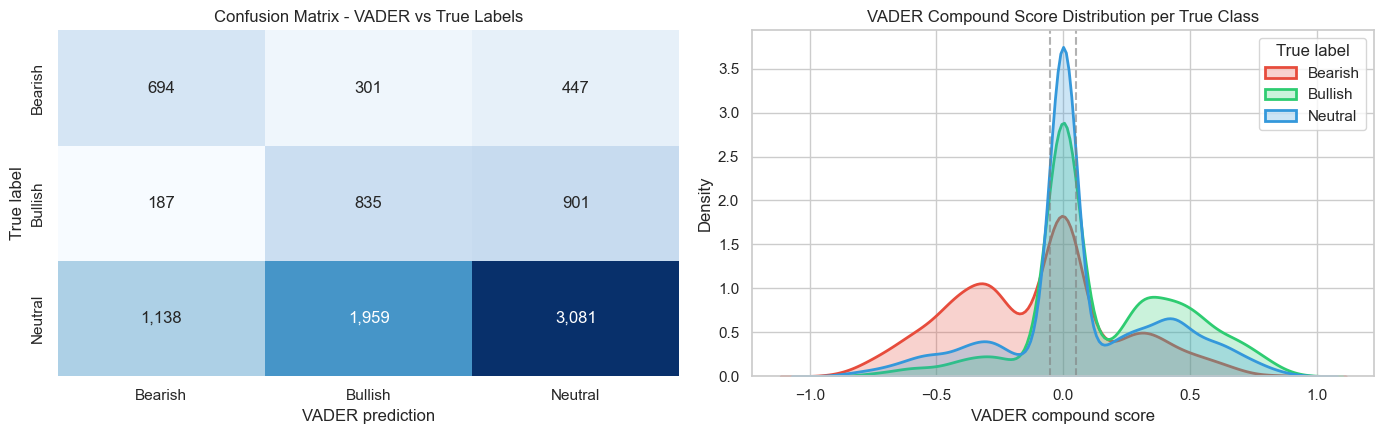

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Confusion matrix
cm = confusion_matrix(train_df['label'], train_df['vader_pred'])
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=ORDER, yticklabels=ORDER,
            cbar=False, ax=axes[0])
axes[0].set_title('Confusion Matrix - VADER vs True Labels')
axes[0].set_xlabel('VADER prediction')
axes[0].set_ylabel('True label')

# VADER compound score distribution per true class
for label in [0, 1, 2]:
    sns.kdeplot(train_df.loc[train_df['label'] == label, 'vader_compound'],
                ax=axes[1], color=PALETTE[label],
                label=LABEL_NAMES[label], linewidth=2, fill=True, alpha=0.25)
axes[1].axvline(-0.05, ls='--', color='gray', alpha=0.6)
axes[1].axvline( 0.05, ls='--', color='gray', alpha=0.6)
axes[1].set_title('VADER Compound Score Distribution per True Class')
axes[1].set_xlabel('VADER compound score')
axes[1].legend(title='True label')

plt.tight_layout()
plt.show()

VADER scores **48.3% accuracy - 16 points *below* the majority-class baseline (64.7%)**. The score distributions show heavy overlap near zero across all three classes, and Neutral tweets are systematically misclassified as Bearish (1,138) or Bullish (1,959). This confirms that a generic social-media lexicon fails to capture financial sentiment - terms like *"misses"*, *"downgrade"* or *"beats estimates"* carry strong directional meaning in this domain that VADER cannot detect. Justifies the use of domain-specific encoders and supervised models in later sections.